### Multi-step, Multi-time, Multivariate Time Series Forecasting.

**Regression: CNN-LSTM, CNN-GRU**


Both models were trained for 10 epochs, with a batch size of 64 and a learning rate of 1e-4. An MSELoss function and the Adam optimizer were used.
This is a multivariate forecasting task, so both temperature and mote_id were used to forecast temperature using a window size of 8. mote_id was encoded as an embedded layer and passed to the model to be optimized during training.


The dataset was split into 80:10:10, that is, 80% for training, 10% for validation, and 10% for testing.

**Classification:**
The dataset was split into 70:20:10,  that is, 70% for training, 20% for validation, and 10% for testing.

CNN-MLP: Trained with a batch size of 64, a learning rate of 1e-4, for 10 epochs, using a CrossEntropy loss function.

CNN-XGBoost: Trained for 100 boosting rounds with early stopping set to 20.
The extracted features from the CNN model were passed as input features to the XGBoost model.

In [1]:
import os
import sys
import json
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
print(os.getcwd())
# Going up one directory from current (notebooks) to the project root
os.chdir("..")
print(os.getcwd())

C:\Users\Nene\iot_sensors_prediction_classification\notebooks
C:\Users\Nene\iot_sensors_prediction_classification


In [3]:
# adding this to sys.path in order to import files from script/ folder
sys.path.append(os.path.join(os.getcwd(), "script"))

In [4]:
with open("config.json", "r") as file:
    config = json.load(file)

In [5]:
from load_data import cls_data_test, pred_data_test
from torch.utils.data import DataLoader
from utils import ClsDataset, PredDataset
from model import *

In [44]:
# autoregression function

def autoregress(model, data_loader, prediction_steps, eval_interval=15):
    window_size = config["window_size"]
    step_range = prediction_steps + window_size
    y_pred = []
    
    model.eval()
    with torch.no_grad():
        for X_num, X_cat, y in data_loader:
            y_true = y

            # Initialize input holder for autoregression
            X_num_hld = torch.zeros((1, training_step + window_size, 1))
            X_num_hld[:, :window_size, :] = X_num[0, :, :].unsqueeze(0) 

            X_cat = X_cat.reshape(-1)

            for i in range(step_range - window_size):
                X_cat_hld = X_cat[i:i+window_size].reshape(1, window_size, 1)
                X_num_input = X_num_hld[:, i:i+window_size, :]

                # Predict next step
                output = model(X_num_input, X_cat_hld)

                y_pred.extend(output.cpu().numpy().flatten())

                # Feed back prediction for autoregression
                X_num_hld[:, window_size + i, :] = output

                # Evaluate metrics every eval_interval steps
                if (i + 1) % eval_interval == 0 and (i + 1) <= len(y_true):
                    mse = mean_squared_error(y_true[:i+1], y_pred)
                    rmse = np.sqrt(mse)
                    mae = mean_absolute_error(y_true[:i+1], y_pred)

                    print(f"Step {i+1}:")
                    print(f"  MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

            break

    return y_pred, y_true

In [6]:
cnnmlp_model = CNNMLP(input_channel=1,output_channel=3,
               num_cnn_layers=2,window_size=5, num_output_units=5)
cnnlstm_model = CNNLSTM(input_size=1, lstm_hidden_units=8, cnn_output_channel=3,
               num_mote_ids=10, embed_dim=2)
cnngru_model = CNNGRU(input_size=1, gru_hidden_units=8, cnn_output_channel=3,
               num_mote_ids=10, gru_hidden_layer=1, embed_dim=2)

cnnmlp_model.load_state_dict(torch.load(config["cnnmlp_model_path"]))
cnnlstm_model.load_state_dict(torch.load(config["cnnlstm_model_path"]))
cnngru_model.load_state_dict(torch.load(config["cnngru_model_path"]))

batch_size = 64

## CNN-MLP

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

test_dataset = cls_data_test()
test_dl = DataLoader(test_dataset, batch_size, shuffle=False)

y_pred = []
y_true = []
cnnmlp_model.eval()
with torch.no_grad():
    for X, y in test_dl:
        outputs = cnnmlp_model(X)
        preds = torch.argmax(outputs, dim=1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(y.cpu().numpy())

In [11]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


Accuracy:  0.7352
Precision: 0.7632
Recall:    0.7352
F1 Score:  0.7323


In [12]:
cls_report = classification_report(y_true, y_pred)
print(cls_report)
# support : display the number of samples for each class
# accuracy: overrall accuracy
#  macro average: takes the average of each metric for all the classes
# weighted average: Takes the average of each metric considering the instances of each metric

              precision    recall  f1-score   support

           0       0.99      0.89      0.94     88676
           1       0.59      0.63      0.61     88676
           2       0.89      0.99      0.94     88676
           3       0.53      0.73      0.61     88676
           4       0.82      0.43      0.56     88676

    accuracy                           0.74    443380
   macro avg       0.76      0.74      0.73    443380
weighted avg       0.76      0.74      0.73    443380



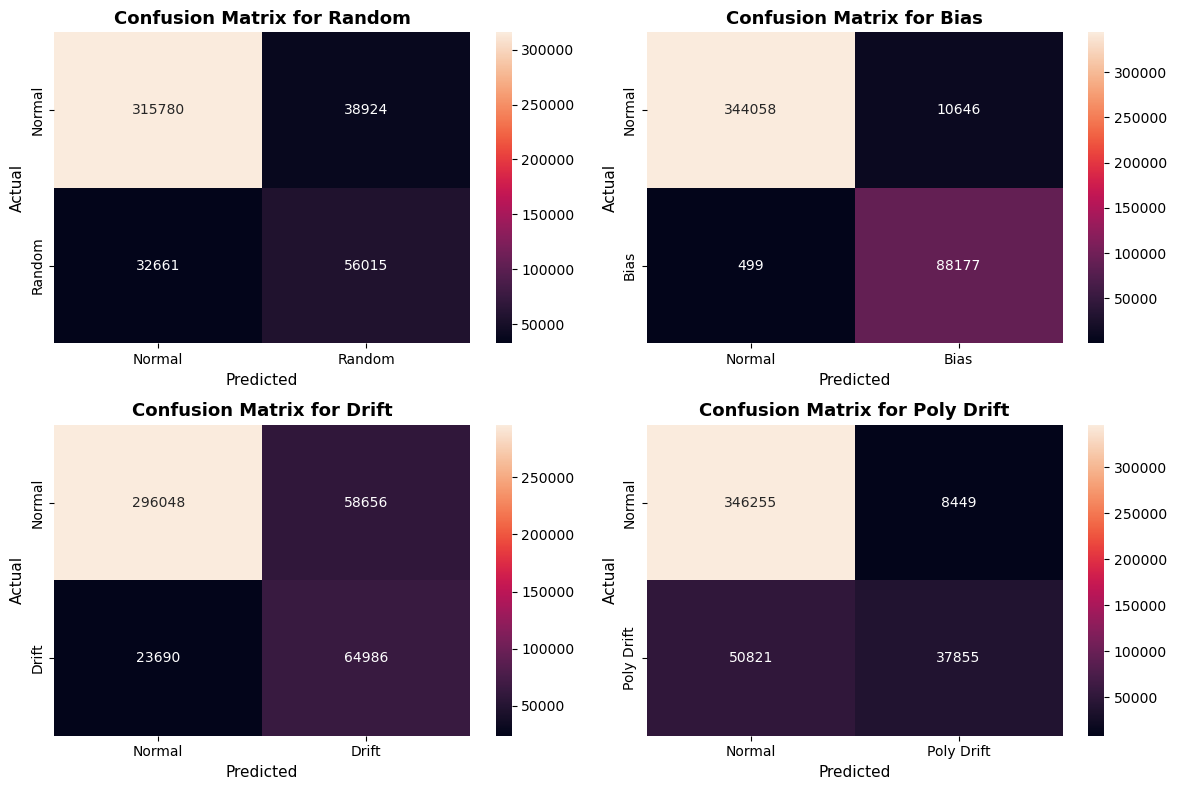

In [13]:
from sklearn.metrics import multilabel_confusion_matrix


# Define class label mappings
label_names = {
    0: "Normal",
    1: "Random",
    2: "Bias",
    3: "Drift",
    4: "Poly Drift"
}

# Compute confusion matrices for each class as one-vs-rest
labels = [0, 1, 2, 3, 4]
mcm = multilabel_confusion_matrix(y_true, y_pred, labels=labels)

# Fault classes to visualize (skip class 0 "Normal")
fault_classes = [1, 2, 3, 4]

# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, cls in enumerate(fault_classes):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    matrix = mcm[cls]
    sns.heatmap(matrix, annot=True, fmt=".0f", cmap="rocket", cbar=True, ax=ax)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(["Normal", label_names[cls]])
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(["Normal", label_names[cls]])
    ax.set_title(f"Confusion Matrix for {label_names[cls]}", fontsize=13, weight='bold')

plt.tight_layout()
plt.show()
# plt.savefig("/Users/Nene/iot_sensors_prediction_classification/figures/cnnmlp_cfmt.png")



## CNN-LSTM

In [45]:
test_dataset = pred_data_test()
test_dl = DataLoader(test_dataset, training_step, shuffle=False)

_ = autoregress(cnnlstm_model, test_dl, 45)

Step 15:
  MSE: 0.0012, RMSE: 0.0351, MAE: 0.0330
Step 30:
  MSE: 0.0025, RMSE: 0.0499, MAE: 0.0470
Step 45:
  MSE: 0.0034, RMSE: 0.0580, MAE: 0.0552


In [ ]:
# from sklearn.metrics import mean_squared_error, mean_absolute_error
# y_pred = []
# y_true = []
# cnnlstm_model.eval()
# with torch.no_grad():
#     for X_num, X_cat, y in test_dl:
#         outputs = cnnlstm_model(X_num,X_cat)

#         y_pred.extend(outputs.cpu().numpy())
#         y_true.extend(y.cpu().numpy())

## CNN-GRU

In [47]:
test_dataset = pred_data_test()
test_dl = DataLoader(test_dataset, training_step, shuffle=False)

_ = autoregress(cnngru_model, test_dl, 45)

Step 15:
  MSE: 0.0017, RMSE: 0.0411, MAE: 0.0384
Step 30:
  MSE: 0.0045, RMSE: 0.0672, MAE: 0.0616
Step 45:
  MSE: 0.0082, RMSE: 0.0905, MAE: 0.0824
